In [1]:
from vizdoom import DoomGame

import random

import time

import numpy as np

from gymnasium import Env

from gymnasium.spaces import Discrete, Box

import cv2

from matplotlib import pyplot as plot

from stable_baselines3.common import env_checker

import os

from stable_baselines3.common.callbacks import BaseCallback

from stable_baselines3 import PPO

In [49]:
class VizDoomGym(Env):
    # Initalizing function
    def __init__(self, render=False):
        super().__init__()
        self.game = DoomGame()
        self.game.load_config('ViZDoom/scenarios/basic.cfg')

        # Render frame logic
        self.game.set_window_visible(render)

        self.game.init()

        self.observation_space = Box(low = 0, high = 255, shape = (100, 160, 1), dtype=np.uint8)

        self.action_space = Discrete(3)

    # What is done when taking a step
    def step(self, action):
        # Specify action then take step
        actions = np.identity(3)
        reward = self.game.make_action(actions[action])

        if self.game.get_state():
            state = self.game.get_state()
            img = state.screen_buffer
            img = self.grayscale(img)
            ammo = state.game_variables[0]
            info = {'ammo': ammo}

        else:
            img = np.zeros(self.observation_space.shape)
            info = {}
        
        done = self.game.is_episode_finished()

        #obs, reward, terminated, truncated, info
        return img, reward, done, False, info

    # Define how to render the game or environment
    def render():
        pass
    
    # What happens when a new game is started
    def reset(self, seed = None, options = None):
        super().reset(seed=seed)
        self.game.new_episode()
        info = {}

        return self.grayscale(self.game.get_state().screen_buffer), info

    # Grayscale the game frame and resize it
    def grayscale(self, observation):
        gray = cv2.cvtColor(np.moveaxis(observation, 0, -1), cv2.COLOR_BGR2GRAY)
        resize = cv2.resize(gray, (160, 100), interpolation=cv2.INTER_CUBIC)
        state = np.reshape(resize, (100, 160, 1))
        return state

    # Will be called to close the game
    def close(self):
        self.game.close()

In [50]:
env = VizDoomGym()

In [51]:
state = env.reset()

In [52]:
state

(array([[[55],
         [50],
         [59],
         ...,
         [57],
         [57],
         [66]],
 
        [[68],
         [65],
         [65],
         ...,
         [56],
         [67],
         [72]],
 
        [[49],
         [79],
         [66],
         ...,
         [79],
         [51],
         [29]],
 
        ...,
 
        [[75],
         [63],
         [62],
         ...,
         [44],
         [71],
         [60]],
 
        [[15],
         [48],
         [47],
         ...,
         [49],
         [69],
         [47]],
 
        [[22],
         [14],
         [26],
         ...,
         [57],
         [37],
         [39]]], shape=(100, 160, 1), dtype=uint8),
 {})

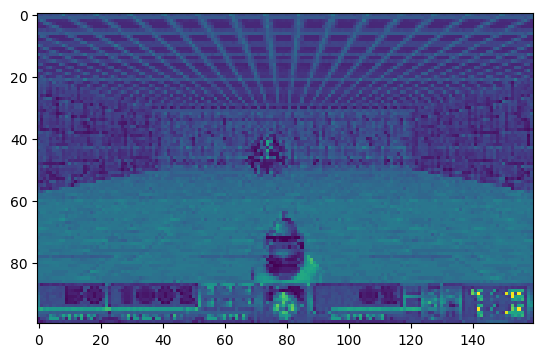

In [53]:
plot.imshow(state[0])

In [54]:
# from stable_baselines3.common import env_checker

In [55]:
env_checker.check_env(env)

In [56]:
env.close()

Setup Callback

In [57]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [4]:
class TrainAndLoggingCallback(BaseCallback):
    def __init__(self, check_freq, save_path, verbose = 1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok = True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)

        return True

In [11]:
CHECKPOINT_DIR = './train/train_basic'
LOG_DIR = 'logs/log_basic'

In [12]:
callback = TrainAndLoggingCallback(check_freq = 10_000, save_path = CHECKPOINT_DIR)

In [50]:
env = VizDoomGym()

In [14]:
model = PPO('CnnPolicy', env, tensorboard_log = LOG_DIR, verbose = 1, learning_rate = 0.0001, n_steps = 2048)

Using cpu device

Wrapping the env with a `Monitor` wrapper

Wrapping the env in a DummyVecEnv.

Wrapping the env in a VecTransposeImage.

In [41]:
from stable_baselines3.common.evaluation import evaluate_policy

In [51]:
model = PPO.load("train/train_basic/best_model_100000")

In [ ]:
env = VizDoomGym(render = True)

In [58]:
mean_reward, _ = evaluate_policy(model, env, n_eval_episodes = 100)

env.close()

c:\Users\austi\Documents\Programming\doom_rl\vizdoom312\Lib\site-packages\stable_baselines3\common\evaluation.py:70
: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting 
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

In [59]:
mean_reward

np.float64(87.06)

In [37]:
action

(array(2), None)

In [66]:
for episode in range(15):
    obs, _ = env.reset()
    done = False
    total_reward = 0
    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, _, info = env.step(action)
        time.sleep(0.01)
        total_reward += reward

    print(f'total reward for episode {episode} is {total_reward}')
    time.sleep(2)

env.close()

total reward for episode 0 is 61.0

total reward for episode 1 is 95.0

total reward for episode 2 is 75.0

total reward for episode 3 is 55.0

total reward for episode 4 is 72.0

...

total reward for episode 10 is 95.0

total reward for episode 11 is 61.0

total reward for episode 12 is 95.0

total reward for episode 13 is 95.0

total reward for episode 14 is 94.0

In [62]:
env.close()

In [15]:
model.learn(total_timesteps=100_000, callback=callback)

Logging to logs/log_basic\PPO_5

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 37.3     |
|    ep_rew_mean     | -112     |
| time/              |          |
|    fps             | 27       |
|    iterations      | 1        |
|    time_elapsed    | 73       |
|    total_timesteps | 2048     |
---------------------------------

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 36.6        |
|    ep_rew_mean          | -107        |
| time/                   |             |
|    fps                  | 17          |
|    iterations           | 2           |
|    time_elapsed         | 237         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008031827 |
|    clip_fraction        | 0.159       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | 0.0002      |
|    learning_rate        | 0.0001      |
|    loss                 | 1.11e+03    |
|    n_updates            | 10          |
|    policy_gradient_loss | 0.00285     |
|    value_loss           | 2.25e+03    |
-----------------------------------------

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 33.7        |
|    ep_rew_mean          | -86.2       |
| time/                   |             |
|    fps                  | 17          |
|    iterations           | 3           |
|    time_elapsed         | 359         |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.006198804 |
|    clip_fraction        | 0.116       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.07       |
|    explained_variance   | 0.0434      |
|    learning_rate        | 0.0001      |
|    loss                 | 1.2e+03     |
|    n_updates            | 20          |
|    policy_gradient_loss | 0.00325     |
|    value_loss           | 3.57e+03    |
-----------------------------------------

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 25.4         |
|    ep_rew_mean          | -33.2        |
| time/                   |              |
|    fps                  | 16           |
|    iterations           | 4            |
|    time_elapsed         | 489          |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0069106985 |
|    clip_fraction        | 0.141        |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.07        |
|    explained_variance   | 0.207        |
|    learning_rate        | 0.0001       |
|    loss                 | 1.02e+03     |
|    n_updates            | 30           |
|    policy_gradient_loss | 0.00134      |
|    value_loss           | 3.02e+03     |
------------------------------------------

...

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.87       |
|    ep_rew_mean          | 87.2       |
| time/                   |            |
|    fps                  | 15         |
|    iterations           | 45         |
|    time_elapsed         | 5849       |
|    total_timesteps      | 92160      |
| train/                  |            |
|    approx_kl            | 0.07448046 |
|    clip_fraction        | 0.069      |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.0692    |
|    explained_variance   | 0.586      |
|    learning_rate        | 0.0001     |
|    loss                 | 14.8       |
|    n_updates            | 440        |
|    policy_gradient_loss | 0.000335   |
|    value_loss           | 66.9       |
----------------------------------------

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.34        |
|    ep_rew_mean          | 85.4        |
| time/                   |             |
|    fps                  | 15          |
|    iterations           | 46          |
|    time_elapsed         | 5988        |
|    total_timesteps      | 94208       |
| train/                  |             |
|    approx_kl            | 0.024699772 |
|    clip_fraction        | 0.0459      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.0655     |
|    explained_variance   | 0.718       |
|    learning_rate        | 0.0001      |
|    loss                 | 27.4        |
|    n_updates            | 450         |
|    policy_gradient_loss | 0.0177      |
|    value_loss           | 39          |
-----------------------------------------

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.24        |
|    ep_rew_mean          | 85.7        |
| time/                   |             |
|    fps                  | 15          |
|    iterations           | 47          |
|    time_elapsed         | 6128        |
|    total_timesteps      | 96256       |
| train/                  |             |
|    approx_kl            | 0.009529208 |
|    clip_fraction        | 0.0479      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.0827     |
|    explained_variance   | 0.875       |
|    learning_rate        | 0.0001      |
|    loss                 | 14.8        |
|    n_updates            | 460         |
|    policy_gradient_loss | 0.0414      |
|    value_loss           | 13.1        |
-----------------------------------------

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.57       |
|    ep_rew_mean          | 88.6       |
| time/                   |            |
|    fps                  | 15         |
|    iterations           | 48         |
|    time_elapsed         | 6278       |
|    total_timesteps      | 98304      |
| train/                  |            |
|    approx_kl            | 0.01632514 |
|    clip_fraction        | 0.0515     |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.0715    |
|    explained_variance   | 0.779      |
|    learning_rate        | 0.0001     |
|    loss                 | 3.37       |
|    n_updates            | 470        |
|    policy_gradient_loss | 0.00895    |
|    value_loss           | 32.5       |
----------------------------------------

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.65        |
|    ep_rew_mean          | 88.4        |
| time/                   |             |
|    fps                  | 15          |
|    iterations           | 49          |
|    time_elapsed         | 6434        |
|    total_timesteps      | 100352      |
| train/                  |             |
|    approx_kl            | 0.009600494 |
|    clip_fraction        | 0.0488      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.0663     |
|    explained_variance   | 0.767       |
|    learning_rate        | 0.0001      |
|    loss                 | 6.39        |
|    n_updates            | 480         |
|    policy_gradient_loss | 0.0137      |
|    value_loss           | 36.5        |
-----------------------------------------